In [ ]:
# Import libraries
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

from pyprojroot import here

## 1. Modify the Port of Varna dataset for testing out ideas.

- Double the cost of DA price to represent balancing market prices
- try to implement my ideas for dispatchable feeder on that

In [2]:
## import data
ROOT_DIR = here()
varna_data = pd.read_parquet(f"{here()}/data/processed/port_energy_data.parquet")

## add new column representing balancing market prices
varna_data["bm_price_usd_kwh"] = varna_data["day_ahead_price_usd_kwh"] * 2
varna_data = varna_data.drop(columns = ["afrr_down_price_usd_kw", "afrr_up_price_usd_kw"])

demand = reefer_demand_kw + total_cold_ironing_demand_kw + office_demand_kw + gantry_crane_demand_kw

generation:
capacity = 920 kW
$\Delta t = \text{1 hour}$

generation per hour timeslot: 
$$ g^{\text{solar}}_t = \text{gen-capacity} * p^{\text{solar}}_t * \Delta t$$

In [3]:
## Create new columns to use for battery optimisation

varna_data["solar_gen_kw"] = 920 * varna_data["solar_generation_pu"] * 1
varna_data["total_demand_kw"] = varna_data[["reefer_demand_kw", "total_cold_ironing_demand_kw",
                                                          "office_demand_kw", "gantry_crane_demand_kw"]].sum(axis=1)
varna_data["prosumption_kw"] = varna_data["total_demand_kw"] - varna_data["solar_gen_kw"]
varna_data.head()

,reefer_demand_kw,total_cold_ironing_demand_kw,day_ahead_price_usd_kwh,office_demand_kw,solar_generation_pu,gantry_crane_demand_kw,bm_price_usd_kwh,solar_gen_kw,total_demand_kw,prosumption_kw
2024-01-01 00:00:00,182.6,0.0,0.000011,24.107,0.0,0.0,0.000022,0.0,206.707,206.707
2024-01-01 01:00:00,182.6,350.0,0.000043,24.457,0.0,0.0,0.000086,0.0,557.057,557.057
2024-01-01 02:00:00,174.4,350.0,0.000011,24.172,0.0,0.0,0.000022,0.0,548.572,548.572
2024-01-01 03:00:00,176.1,350.0,0.000011,24.819,0.0,0.0,0.000022,0.0,550.919,550.919
2024-01-01 04:00:00,182.6,350.0,0.000011,25.541,0.0,0.0,0.000022,0.0,558.141,558.141


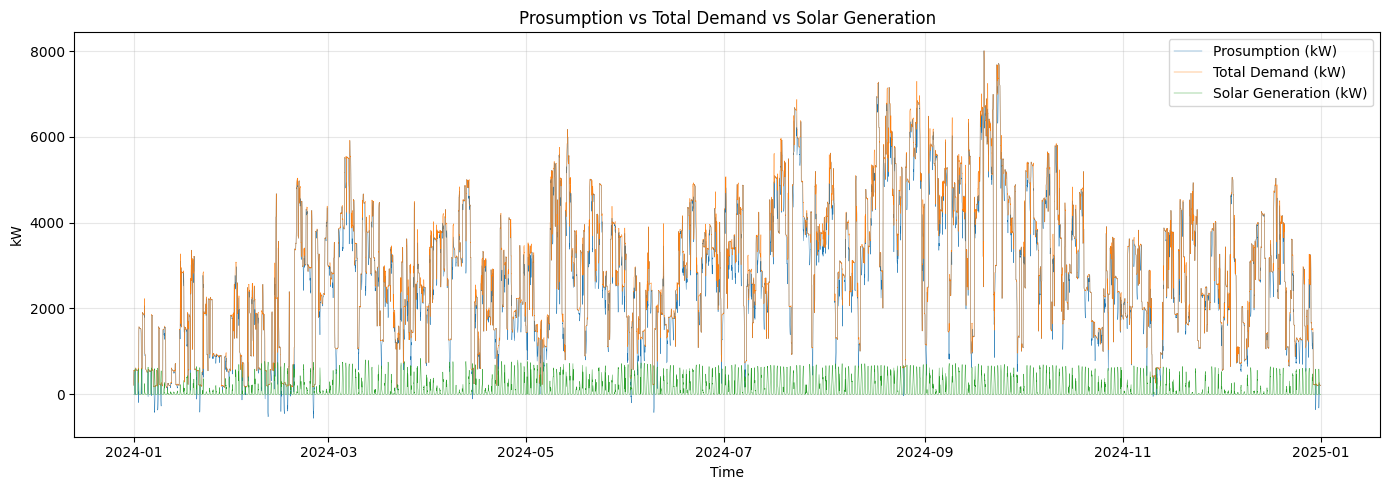

In [4]:
midpoint = len(varna_data) // 2

#varna_subset = varna_data.iloc[:midpoint]
varna_subset = varna_data

# Plot prosumption vs total demand and their difference
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(varna_subset.index, varna_subset["prosumption_kw"], label="Prosumption (kW)", alpha=1, linewidth = 0.3)
ax.plot(varna_subset.index, varna_subset["total_demand_kw"], label="Total Demand (kW)", alpha=1, linewidth = 0.3)
ax.plot(varna_subset.index, varna_subset["solar_gen_kw"], label="Solar Generation (kW)", alpha=1, linewidth = 0.3)

ax.set_title("Prosumption vs Total Demand vs Solar Generation")
ax.set_xlabel("Time")
ax.set_ylabel("kW")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

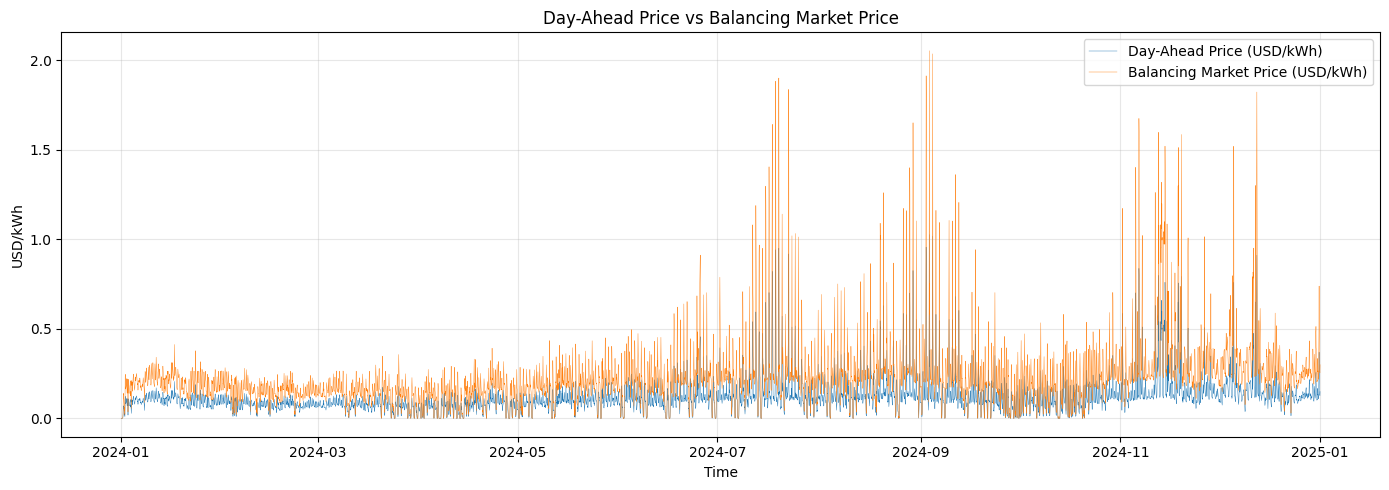

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    varna_data.index,
    varna_data["day_ahead_price_usd_kwh"],
    label="Day-Ahead Price (USD/kWh)",
    alpha=1, linewidth = 0.3
)

ax.plot(
    varna_data.index,
    varna_data["bm_price_usd_kwh"],
    label="Balancing Market Price (USD/kWh)",
    alpha=1, linewidth = 0.3,
)

ax.set_title("Day-Ahead Price vs Balancing Market Price")
ax.set_xlabel("Time")
ax.set_ylabel("USD/kWh")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
df = varna_data[["prosumption_kw", "day_ahead_price_usd_kwh", "bm_price_usd_kwh"]]
df.describe()

,prosumption_kw,day_ahead_price_usd_kwh,bm_price_usd_kwh
count,8784.000000,8784.000000,8784.000000
mean,2751.685971,0.110803,0.221606
std,1588.680946,0.087928,0.175855
min,-561.756400,0.000000,0.000000
25%,1531.010550,0.071566,0.143132
50%,2665.225400,0.098161,0.196322
75%,3826.207400,0.127197,0.254394
max,8009.248000,1.026011,2.052022


In [7]:

columns_mapping = {"prosumption_kw": "pro",
 "day_ahead_price_usd_kwh" : "da_price",
 "bm_price_usd_kwh": "bm_price"
 }

df = df.rename(columns = columns_mapping)

## Create fake forecast values
df["fc_pro"] = df["pro"] + np.random.normal(-(1588.680946/1000), (1588.680946/1000), size=len(df))
df["fc_da_price"] = df["da_price"] + np.random.normal(-(0.087928/1000), (0.087928/1000), size=len(df))
df["fc_bm_price"] = df["bm_price"] + np.random.normal(-(0.175855/1000), (0.175855/1000), size=len(df))

df.head()

,pro,da_price,bm_price,fc_pro,fc_da_price,fc_bm_price
2024-01-01 00:00:00,206.707,0.000011,0.000022,208.950361,-0.000164,-0.000286
2024-01-01 01:00:00,557.057,0.000043,0.000086,556.196872,-0.000154,0.000037
2024-01-01 02:00:00,548.572,0.000011,0.000022,548.773538,-0.000185,-0.000391
2024-01-01 03:00:00,550.919,0.000011,0.000022,553.322649,-0.000184,-0.000079
2024-01-01 04:00:00,558.141,0.000011,0.000022,557.253509,-0.000002,-0.000034


## 2. Test out optimisation ideas.

In [32]:
##1. Day ahead scheduling for a single day under perfect foresight

start_day = "2024-06-01"
end_day = "2024-06-02"

test_days = df.loc[start_day : end_day]
test_days_index = test_days.index
test_days = test_days.reset_index()
test_days = test_days.drop(columns = ["index"])
#print(test_days)

T = 48  # 24-hour scheduling horizon

# Battery Limits (using rough Port/1MW scale estimates)
E_MAX = 2000.0       # Max battery capacity in kWh
E_MIN = 0.0          # Min battery capacity in kWh
P_BAT_MAX = 500.0   # Max charge/discharge rate in kW
SOC_INIT = 0.0    # State of Charge at the start of the day

def da_problem_builder(T, E_MAX, E_MIN, P_BAT_MAX, SOC_INIT, pro, da_price):

    P_s = cp.Variable(T, name = "P_s")             # Battery power (positive=charge, negative=discharge)
    E_s = cp.Variable(T + 1, name = "E_s")         # Battery state of energy
    P_da = cp.Variable(T, name = "P_da")             # Scheduled DA consumption (equal to prosumption + battery power, want to minimise this)

    constraints_L1 = [
        E_s[0] == SOC_INIT,          # Set initial state of charge
        P_s <= P_BAT_MAX,            # Battery charge limit
        P_s >= -P_BAT_MAX,           # Battery discharge limit
        E_s <= E_MAX,                # Max capacity limit
        E_s >= E_MIN                 # Min capacity limit
    ]

    # Add dynamic equations for all 24 hours
    for k in range(T):
        # Energy conservation: Next State = Current State + Power
        # (Assuming Delta t = 1 hour, and ignoring efficiency loss for MVP clarity)
        constraints_L1.append(E_s[k+1] == E_s[k] + P_s[k])

        # Power balance: Grid Power = Battery Power +  Prosumption
        constraints_L1.append(P_da[k] == P_s[k] + pro[k])

    # Define Objective: Minimize cost of scheduling DA power
    cost_L1 = P_da.T @ da_price
    # Solve Level 1
    prob_L1 = cp.Problem(cp.Minimize(cost_L1), constraints_L1)
    return prob_L1


da_problem = da_problem_builder(T, E_MAX, E_MIN, P_BAT_MAX, SOC_INIT, test_days["pro"], test_days["da_price"])

da_problem.solve(verbose = True, solver=cp.GUROBI)

results_dict = {key: var.value for key, var in da_problem.var_dict.items()}
df_results = pd.DataFrame.from_dict(results_dict, orient='index').transpose()
df_plot_results = pd.concat([test_days,df_results], axis = 1).set_index(df.loc[start_day : (dt.datetime.strptime(end_day, "%Y-%m-%d") + dt.timedelta(hours=24))].index)

(CVXPY) Jun 19 12:59:14 PM: Your problem has 145 variables, 291 constraints, and 0 parameters.
(CVXPY) Jun 19 12:59:14 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jun 19 12:59:14 PM: DCP verification time: 0.0117 seconds.
(CVXPY) Jun 19 12:59:14 PM: Expression tree has 3 nodes.
(CVXPY) Jun 19 12:59:14 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jun 19 12:59:14 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jun 19 12:59:14 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jun 19 12:59:14 PM: Compiling problem (target solver=GUROBI).
(CVXPY) Jun 19 12:59:14 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> EliminateZeroSized -> ConeMatrixStuffing -> GUROBI
(CVXPY) Jun 19 12:59:14 PM: Applying reduction Dcp2Cone
(CVXPY) Jun 19 12:59:14 PM: Applying reduction CvxAttr2Constr
(CVXPY) Jun 19 12:59:14 PM: App

                                     CVXPY                                     
                                     v1.9.1                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
Set parameter OutputFlag to value 1
Set parameter QCPDual to value 1
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 24.04.1 LTS")

CPU model: Intel(R) Core(TM) i5-8365U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
QCPDual  1

Academic l

(CVXPY) Jun 19 12:59:14 PM: Problem status: optimal
(CVXPY) Jun 19 12:59:14 PM: Optimal value: 3.670e+03
(CVXPY) Jun 19 12:59:14 PM: Compilation took 1.054e-01 seconds
(CVXPY) Jun 19 12:59:14 PM: Solver (including time spent in interface) took 5.969e-02 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


In [10]:
df_plot_results.head()

,pro,da_price,bm_price,fc_pro,fc_da_price,fc_bm_price,P_da,E_s,P_s
0,1795.9040,0.080514,0.161028,1796.897513,0.080399,0.160935,2295.9040,0.0,500.0
1,1801.8850,0.081788,0.163577,1800.601122,0.081712,0.163323,1301.8850,500.0,-500.0
2,1800.4190,0.072457,0.144914,1798.285758,0.072343,0.144859,2300.4190,0.0,500.0
3,1809.5530,0.072835,0.145670,1810.389158,0.072753,0.145391,2309.5530,500.0,500.0
4,1043.1138,0.078332,0.156665,1040.781256,0.078111,0.156399,543.1138,1000.0,-500.0


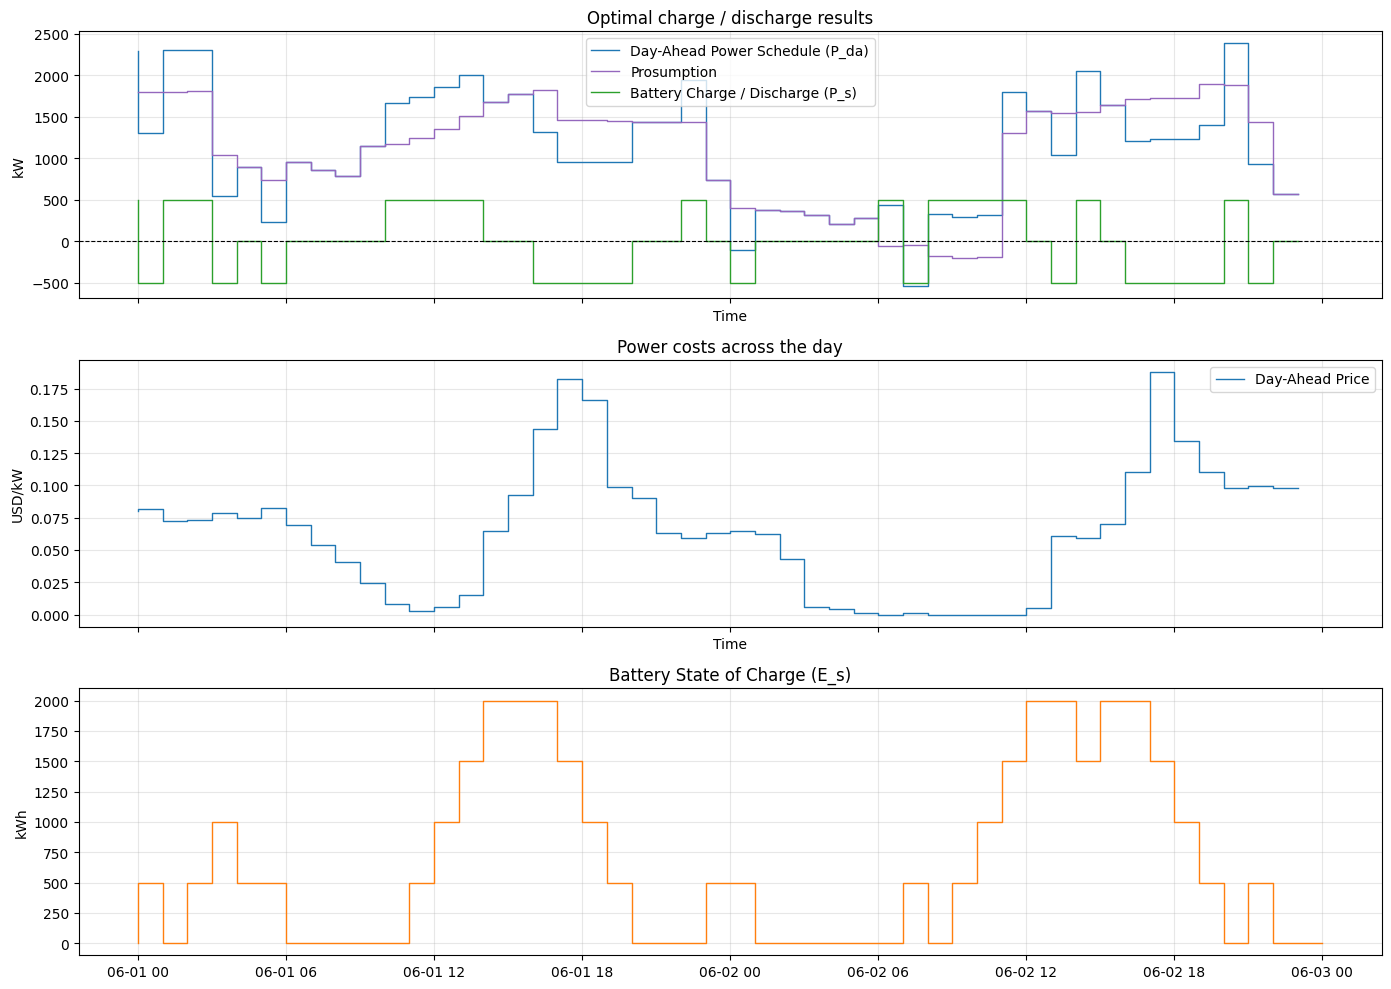

3670.2217756795226


In [33]:
def plot_results (df_plot_results):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    axes[0].step(df_plot_results.index, df_plot_results["P_da"], label="Day-Ahead Power Schedule (P_da)", alpha=1, linewidth = 1)
    axes[0].step(df_plot_results.index, df_plot_results["pro"], label="Prosumption", alpha=1, linewidth = 1, color="tab:purple")
    axes[0].step(df_plot_results.index, df_plot_results["P_s"], label="Battery Charge / Discharge (P_s)", alpha=1, linewidth = 1, color="tab:green")

    axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[0].set_title("Optimal charge / discharge results")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("kW")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].step(df_plot_results.index, df_plot_results["da_price"], label="Day-Ahead Price", alpha=1, linewidth = 1)

    axes[1].set_title("Power costs across the day")
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("USD/kW")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].step(df_plot_results.index, df_plot_results["E_s"], linewidth=1, color="tab:orange")
    axes[2].set_title("Battery State of Charge (E_s)")
    axes[2].set_ylabel("kWh")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def get_result_metrics(df_plot_results):
    total_cost = (df_plot_results["da_price"] * df_plot_results["P_da"]).sum()
    return total_cost

plot_results(df_plot_results)

print(get_result_metrics(df_plot_results))